In [7]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
#from celluloid import camera
from scipy.integrate import solve_ivp

In [4]:
def edm_pendulo_simple(t, Ys, g, L):
    teta, u = Ys
    dteta_dt = u
    du_dt = - (g / L) * np.sin(teta)

    return [dteta_dt, du_dt]

In [5]:
edm_pendulo_simple(1, [1, 1], 1, 1)

[1, np.float64(-0.8414709848078965)]

In [12]:
ts = np.linspace(0, 10, 100)
Y0s = [40*np.pi/180, 0]
g = 9.81 # m/s^2
L = 1 # m
sol = solve_ivp(
    edm_pendulo_simple, 
    [ts[0], ts[-1]],
    Y0s, 
    t_eval = ts,
    args = (g, L)
)
#Variables de configuración
tetas = sol.y[0]
us = sol.y[1]

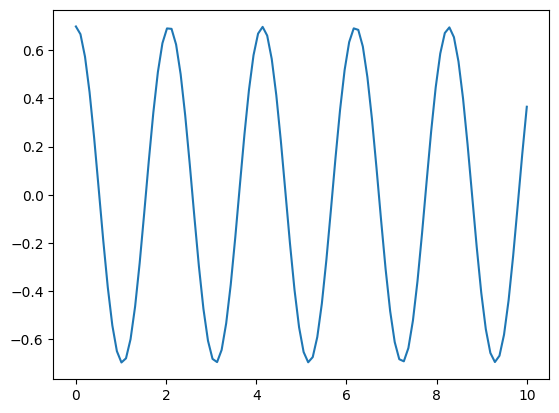

In [11]:
plt.plot(ts, tetas)

Coordenadas

(np.float64(-0.7052356451580338),
 np.float64(0.7069791932505666),
 np.float64(-1.011687720486852),
 np.float64(-0.7543471441966983))

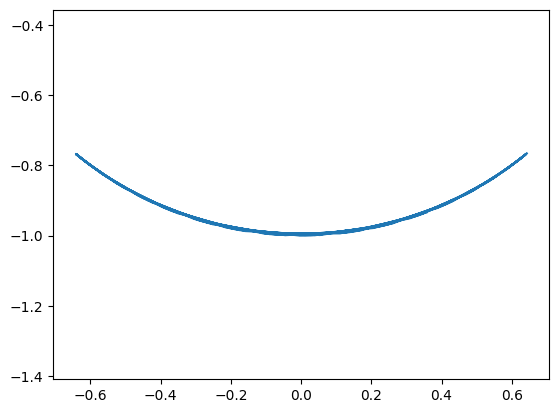

In [13]:
xs = L * np.sin(tetas)
ys = - L * np.cos(tetas)

plt.plot(xs, ys)
plt.axis('equal')

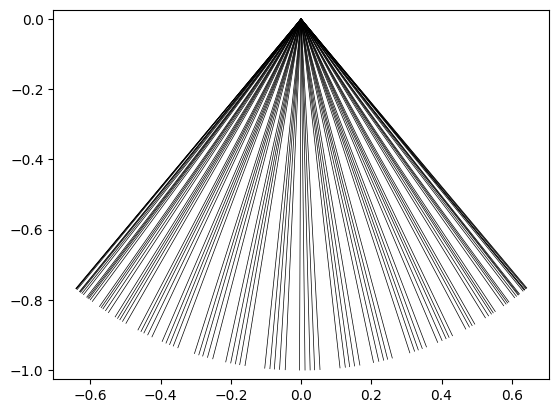

In [24]:
# Animación
from celluloid import Camera

fig = plt.figure()
camara = Camera(fig)

for i, t in enumerate(ts):
    plt.plot([0, xs[i]], [0, ys[i]], 'k-', lw = 0.5)
    camara.snap()

    plt.axis('equal')
    

In [22]:
from IPython.display import HTML
anim = camara.animate()
HTML(anim.to_jshtml())